# Case Study 53 - Liver Cirrhosis & Disease Pattern Classification
**Course:** Machine Learning - B.Tech CSE (2024-28) - Semester V  
**Project Title:** *HepatoPattern - Classification of Liver Disease & Cirrhosis from Blood Tests*

---

Name: Rohan Vashisht

Cohort: Jensen Huang

Roll No.: 150096724132

---

Streamlit App: https://hepato-pattern-ml-rohanv.streamlit.app/

Google Colab:  https://colab.research.google.com/drive/1WG9aCzu0jXaWvWpKdhbmRw1qDQhmHv1C

UCI Dataset:   https://archive.ics.uci.edu/dataset/571/hcv+data

GitHub Repo:   https://github.com/RohanVashisht1234/hepato-pattern-ml

---

## 1. Problem Definition & Objectives

### 1.1 Objective
The goal is to develop a machine learning system that classifies whether a patient has **Active Liver Disease (Hepatitis / Fibrosis / Cirrhosis)** or has **Normal Liver Function (Healthy Blood Donor)** using standard blood test results.

* **Class 0 (Negative) - Healthy Blood Donors**: Certified healthy blood donors with normal liver enzyme levels (`0=Blood Donor` and `0s=suspect Blood Donor`).
* **Class 1 (Positive) - Active Liver Pathology**: Patients diagnosed with progressive liver disease (`1=Hepatitis`, `2=Fibrosis`, `3=Cirrhosis`).

### 1.2 Core Machine Learning Setup
* **Task Type**: Supervised Binary Classification.
* **Input Features**: 12 routine and biochemical blood markers (Age, Sex, ALT, AST, Bilirubin, Albumin, etc.).
* **Output**: Predicted class (0 = Healthy, 1 = Liver Disease) and disease probability.
* **Primary Metrics**: Accuracy, ROC-AUC, Recall, Precision, and Confusion Matrix.

## 2. Dataset Loading & Inspection

### 2.1 Clinical Dataset Origin (UCI Machine Learning Repository)
The dataset used in this project is an authentic clinical cohort obtained from the official **UCI Machine Learning Repository**:
* **Repository Source:** UCI Machine Learning Repository (Dataset ID #571)
* **Dataset Name:** HCV Data (Hepatitis C & Liver Disease Progression)
* **Direct Zip URL:** `https://archive.ics.uci.edu/static/public/571/hcv+data.zip`
* **Clinical Origin:** Hannover Medical School (Medizinische Hochschule Hannover, Germany)
* **Authors:** Dr. Ralf Lichtinghagen, Prof. Frank Klawonn, Gottfried Uhlig
* **Patient Records:** 615 real patient observations (540 healthy blood donor controls, 75 liver disease progression patients across Hepatitis, Fibrosis, and Cirrhosis)

The code block below automatically fetches the official ZIP archive directly from the UCI server if needed, extracts the original clinical file (`hcvdat0.csv`), and verifies the dataset integrity.

In [ ]:
!pip install pandas matplotlib seaborn scikit-learn joblib

In [ ]:
import os
import io
import urllib.request
import zipfile
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

plt.style.use(
    "seaborn-v0_8-whitegrid"
    if "seaborn-v0_8-whitegrid" in plt.style.available
    else "default"
)

plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]

UCI_DATASET_DOWNLOAD_URL = "https://archive.ics.uci.edu/static/public/571/hcv+data.zip"
LOCAL_CSV_FILE_PATH = "cirrhosis.csv"


def download_uci_dataset_if_needed(dataset_download_url, local_csv_file_path):
    if os.path.exists(local_csv_file_path):
        print(f"Verified dataset already present locally: '{local_csv_file_path}'")
        print(f"Official UCI Repository Source: {dataset_download_url}")
        return

    print("Downloading dataset from UCI Machine Learning Repository:")
    print(f"URL: {dataset_download_url}")

    download_request = urllib.request.Request(
        dataset_download_url,
        headers={"User-Agent": "Mozilla/5.0"}
    )

    with urllib.request.urlopen(download_request) as download_response:
        downloaded_zip_data = io.BytesIO(download_response.read())

    with zipfile.ZipFile(downloaded_zip_data) as downloaded_zip_file:
        with downloaded_zip_file.open("hcvdat0.csv") as dataset_file:
            liver_disease_dataframe = pd.read_csv(dataset_file)

    liver_disease_dataframe.drop(
        columns=["Unnamed: 0"],
        errors="ignore"
    ).to_csv(local_csv_file_path, index=False)

    print(f"Successfully downloaded and extracted to '{local_csv_file_path}'.")


download_uci_dataset_if_needed(
    UCI_DATASET_DOWNLOAD_URL,
    LOCAL_CSV_FILE_PATH
)

liver_disease_dataframe = pd.read_csv(LOCAL_CSV_FILE_PATH)

liver_disease_dataframe.drop(
    columns=["Unnamed: 0"],
    errors="ignore",
    inplace=True
)

print(
    f"Dataset Shape: {liver_disease_dataframe.shape[0]} rows, "
    f"{liver_disease_dataframe.shape[1]} columns"
)

liver_disease_dataframe.head()

Verified dataset already present locally: 'cirrhosis.csv'
Official UCI Repository Source: https://archive.ics.uci.edu/static/public/571/hcv+data.zip
Dataset Shape: 615 rows, 13 columns


,Category,Age,Sex,ALB,ALP,ALT,AST,BIL,CHE,CHOL,CREA,GGT,PROT
0,0=Blood Donor,32,m,38.5,52.5,7.7,22.1,7.5,6.93,3.23,106.0,12.1,69.0
1,0=Blood Donor,32,m,38.5,70.3,18.0,24.7,3.9,11.17,4.80,74.0,15.6,76.5
2,0=Blood Donor,32,m,46.9,74.7,36.2,52.6,6.1,8.84,5.20,86.0,33.2,79.3
3,0=Blood Donor,32,m,43.2,52.0,30.6,22.6,18.9,7.33,4.74,80.0,33.8,75.7
4,0=Blood Donor,32,m,39.2,74.1,32.6,24.8,9.6,9.15,4.32,76.0,29.9,68.7


In [ ]:
# Check missing values
missing_value_counts = liver_disease_dataframe.isnull().sum()

print("Missing Values Count:")
print(missing_value_counts[missing_value_counts > 0])

Missing Values Count:
ALB      1
ALP     18
ALT      1
CHOL    10
PROT     1
dtype: int64


## 3. Exploratory Data Analysis (EDA)

We explore the distribution of patient diagnoses and see how liver enzymes behave in healthy vs. diseased patients.

In [ ]:
# Data Preparation
liver_disease_dataframe['Sex_code'] = liver_disease_dataframe['Sex'].map({'m': 1, 'f': 0})
liver_disease_dataframe['target'] = liver_disease_dataframe['Category'].apply(
    lambda category: 0 if 'Blood Donor' in str(category) else 1
)

print("Target Distribution:")
print(liver_disease_dataframe['target'].value_counts())

healthy_donor_count = (liver_disease_dataframe['target'] == 0).sum()
active_disease_count = (liver_disease_dataframe['target'] == 1).sum()

print(
    f"Healthy Donors (0): {healthy_donor_count} "
    f"({healthy_donor_count / len(liver_disease_dataframe) * 100:.1f}%)"
)

print(
    f"Active Disease (1): {active_disease_count} "
    f"({active_disease_count / len(liver_disease_dataframe) * 100:.1f}%)"
)

Target Distribution:
target
0    540
1     75
Name: count, dtype: int64
Healthy Donors (0): 540 (87.8%)
Active Disease (1): 75 (12.2%)


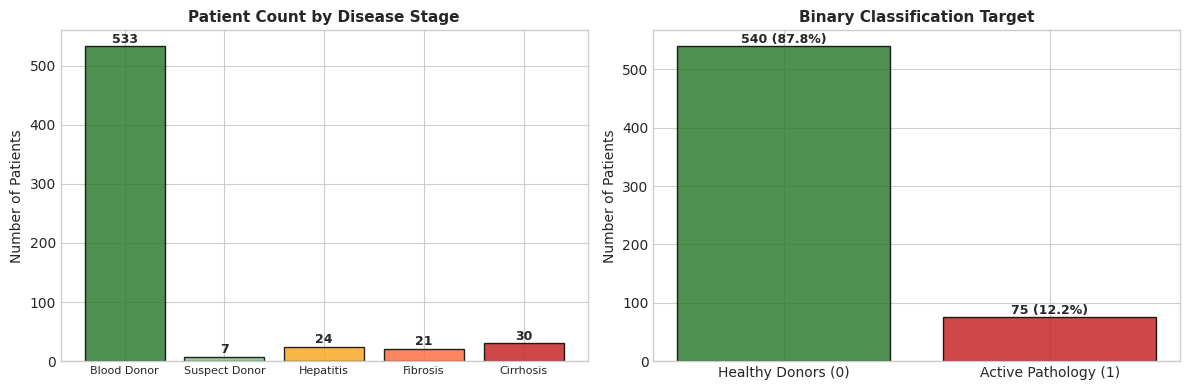

In [ ]:
# Figure 1: Class Breakdown and Disease Progression
figure, (stage_axis, target_axis) = plt.subplots(1, 2, figsize=(12, 4))

disease_categories = [
    '0=Blood Donor',
    '0s=suspect Blood Donor',
    '1=Hepatitis',
    '2=Fibrosis',
    '3=Cirrhosis'
]

disease_category_names = [
    'Blood Donor',
    'Suspect Donor',
    'Hepatitis',
    'Fibrosis',
    'Cirrhosis'
]

disease_category_colors = [
    '#2E7D32',
    '#81C784',
    '#F9A825',
    '#FF7043',
    '#C62828'
]

disease_category_counts = [
    sum(liver_disease_dataframe['Category'] == category)
    for category in disease_categories
]

stage_bars = stage_axis.bar(
    range(5),
    disease_category_counts,
    color=disease_category_colors,
    edgecolor='black',
    alpha=0.85
)

for bar in stage_bars:
    stage_axis.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 6,
        int(bar.get_height()),
        ha='center',
        fontweight='bold',
        fontsize=9
    )

stage_axis.set_title(
    'Patient Count by Disease Stage',
    fontsize=11,
    fontweight='bold'
)
stage_axis.set_xticks(range(5))
stage_axis.set_xticklabels(disease_category_names, fontsize=8)
stage_axis.set_ylabel('Number of Patients')


target_counts = [
    sum(liver_disease_dataframe['target'] == 0),
    sum(liver_disease_dataframe['target'] == 1)
]

target_bars = target_axis.bar(
    ['Healthy Donors (0)', 'Active Pathology (1)'],
    target_counts,
    color=['#2E7D32', '#C62828'],
    edgecolor='black',
    alpha=0.85
)

for bar in target_bars:
    patient_count = int(bar.get_height())
    target_axis.text(
        bar.get_x() + bar.get_width() / 2,
        patient_count + 6,
        f"{patient_count} ({patient_count / len(liver_disease_dataframe) * 100:.1f}%)",
        ha='center',
        fontweight='bold',
        fontsize=9
    )

target_axis.set_title(
    'Binary Classification Target',
    fontsize=11,
    fontweight='bold'
)
target_axis.set_ylabel('Number of Patients')

plt.tight_layout()
plt.show()

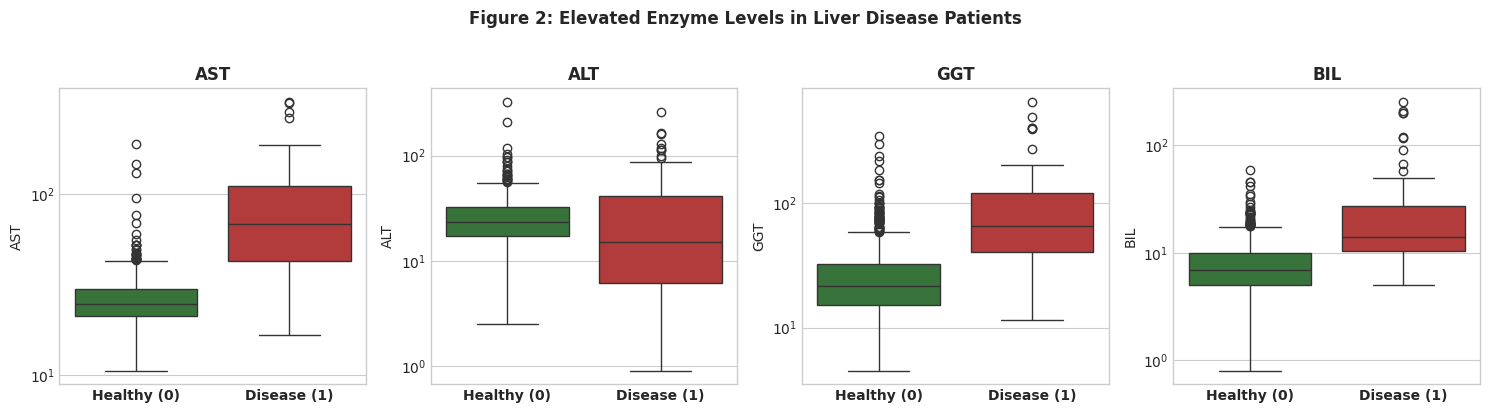

In [ ]:
# Figure 2: Key Liver Biomarkers Comparison (AST, ALT, GGT, Bilirubin)
figure, biomarker_axes = plt.subplots(1, 4, figsize=(15, 4))

liver_biomarker_names = ['AST', 'ALT', 'GGT', 'BIL']

for biomarker_index, biomarker_name in enumerate(liver_biomarker_names):
    biomarker_dataframe = liver_disease_dataframe.dropna(subset=[biomarker_name])

    sns.boxplot(
        data=biomarker_dataframe,
        x='target',
        y=biomarker_name,
        ax=biomarker_axes[biomarker_index],
        palette=['#2E7D32', '#C62828'],
        hue='target',
        legend=False
    )

    biomarker_axes[biomarker_index].set_yscale('log')
    biomarker_axes[biomarker_index].set_xticklabels(
        ['Healthy (0)', 'Disease (1)'],
        fontweight='bold'
    )
    biomarker_axes[biomarker_index].set_title(
        biomarker_name,
        fontweight='bold'
    )
    biomarker_axes[biomarker_index].set_xlabel('')

plt.suptitle(
    'Figure 2: Elevated Enzyme Levels in Liver Disease Patients',
    fontsize=12,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

## 4. Preprocessing & Train/Test Split
We split the data into 80% training (492 patients) and 20% held-out testing (123 patients).  
To prevent data leakage, missing value imputation (`SimpleImputer(median)`) and normalization (`StandardScaler`) are packaged strictly inside scikit-learn Pipelines.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

full_feature_names = [
    'Age', 'Sex_code', 'ALB', 'ALP', 'ALT', 'AST',
    'BIL', 'CHE', 'CHOL', 'CREA', 'GGT', 'PROT'
]

routine_feature_names = [
    'Age', 'Sex_code', 'ALB', 'ALT', 'AST', 'BIL'
]

full_features = liver_disease_dataframe[full_feature_names]
target = liver_disease_dataframe['target']

training_features, testing_features, training_target, testing_target = train_test_split(
    full_features,
    target,
    test_size=0.20,
    random_state=42,
    stratify=target
)

print(
    f"Training Samples: {len(training_features)} "
    f"({training_target.sum()} diseased, "
    f"{len(training_target) - training_target.sum()} donors)"
)

print(
    f"Testing Samples: {len(testing_features)} "
    f"({testing_target.sum()} diseased, "
    f"{len(testing_target) - testing_target.sum()} donors)"
)

Training Samples: 492 (60 diseased, 432 donors)
Testing Samples: 123 (15 diseased, 108 donors)


## 5. Machine Learning Models Benchmark

We compare three foundational machine learning paradigms using **5-Fold Stratified Cross-Validation (3 repeats = 15 folds)**:
1. **Simple Linear Model**: `Logistic Regression` (Linear Decision Boundary)
2. **Tree-based Model**: `Decision Tree` (Single Decision Tree)
3. **Advanced Ensemble Model**: `Random Forest` (200 de-correlated trees)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate

classification_models = {
    'Logistic Regression (Linear)': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree (Tree-based)': DecisionTreeClassifier(max_depth=4, random_state=42),
    'Random Forest (Ensemble)': RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    )
}

cross_validation_strategy = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=3,
    random_state=42
)

evaluation_metrics = ['accuracy', 'f1', 'recall', 'roc_auc']

model_evaluation_results = []

for model_name, classification_model in classification_models.items():
    model_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('classifier', classification_model)
    ])

    cross_validation_scores = cross_validate(
        model_pipeline,
        training_features,
        training_target,
        cv=cross_validation_strategy,
        scoring=evaluation_metrics,
        n_jobs=1
    )

    model_evaluation_results.append({
        'Model': model_name,
        'CV Accuracy': cross_validation_scores['test_accuracy'].mean(),
        'CV F1-Score': cross_validation_scores['test_f1'].mean(),
        'CV Recall': cross_validation_scores['test_recall'].mean(),
        'CV ROC-AUC': cross_validation_scores['test_roc_auc'].mean()
    })

model_evaluation_dataframe = (
    pd.DataFrame(model_evaluation_results)
    .sort_values(by='CV Accuracy', ascending=False)
    .reset_index(drop=True)
)

print("=== 5x3 Cross-Validation Results ===")
display(model_evaluation_dataframe.round(3))

=== 5x3 Cross-Validation Results ===


,Model,CV Accuracy,CV F1-Score,CV Recall,CV ROC-AUC
0,Random Forest (Ensemble),0.959,0.813,0.739,0.978
1,Logistic Regression (Linear),0.953,0.771,0.700,0.968
2,Decision Tree (Tree-based),0.947,0.767,0.717,0.836


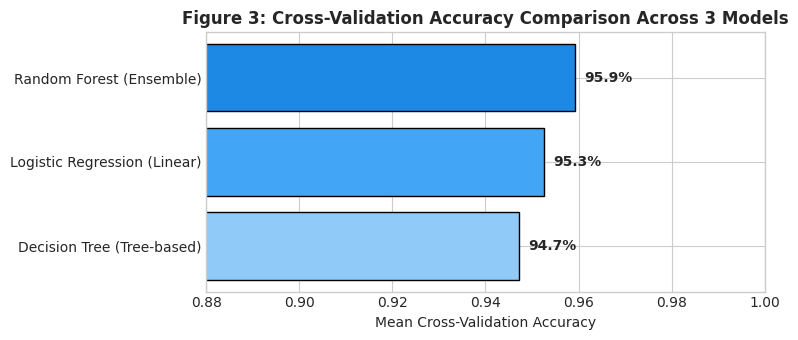

In [ ]:
# Figure 3: Model Comparison Chart
plt.figure(figsize=(8, 3.5))

sorted_model_evaluation_dataframe = model_evaluation_dataframe.sort_values(
    by='CV Accuracy',
    ascending=True
)

model_accuracy_bars = plt.barh(
    sorted_model_evaluation_dataframe['Model'],
    sorted_model_evaluation_dataframe['CV Accuracy'],
    color=['#90CAF9', '#42A5F5', '#1E88E5'],
    edgecolor='black'
)

plt.xlim(0.88, 1.0)
plt.xlabel('Mean Cross-Validation Accuracy')
plt.title(
    'Figure 3: Cross-Validation Accuracy Comparison Across 3 Models',
    fontweight='bold'
)

for bar in model_accuracy_bars:
    accuracy_value = bar.get_width()
    plt.text(
        accuracy_value + 0.002,
        bar.get_y() + bar.get_height() / 2,
        f"{accuracy_value * 100:.1f}%",
        va='center',
        fontweight='bold'
    )

plt.tight_layout()
plt.show()

## 6. Feature Panel Experiment (Submission Requirement)

We compare the performance of:
* **Full Clinical Blood Panel (12 features)**: Complete lab battery.
* **Routine Outpatient LFT Panel (6 features)**: Standard basic tests (`Age`, `Sex`, `ALB`, `ALT`, `AST`, `BIL`).

In [ ]:
# Compare Full vs Routine Panel using Random Forest

random_forest_full_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    ))
])

random_forest_routine_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        random_state=42
    ))
])

random_forest_full_pipeline.fit(training_features, training_target)
random_forest_routine_pipeline.fit(
    training_features[routine_feature_names],
    training_target
)

from sklearn.metrics import accuracy_score, roc_auc_score

full_panel_accuracy = accuracy_score(
    testing_target,
    random_forest_full_pipeline.predict(testing_features)
)

full_panel_roc_auc = roc_auc_score(
    testing_target,
    random_forest_full_pipeline.predict_proba(testing_features)[:, 1]
)

routine_panel_accuracy = accuracy_score(
    testing_target,
    random_forest_routine_pipeline.predict(
        testing_features[routine_feature_names]
    )
)

routine_panel_roc_auc = roc_auc_score(
    testing_target,
    random_forest_routine_pipeline.predict_proba(
        testing_features[routine_feature_names]
    )[:, 1]
)

print("=== Feature Panel Comparison on Held-Out Test Set ===")
print(
    f"Full Clinical Panel (12 features):   "
    f"Accuracy = {full_panel_accuracy * 100:.2f}% | "
    f"ROC-AUC = {full_panel_roc_auc:.4f}"
)

print(
    f"Routine Outpatient LFT (6 features): "
    f"Accuracy = {routine_panel_accuracy * 100:.2f}% | "
    f"ROC-AUC = {routine_panel_roc_auc:.4f}"
)

=== Feature Panel Comparison on Held-Out Test Set ===
Full Clinical Panel (12 features):   Accuracy = 97.56% | ROC-AUC = 0.9969
Routine Outpatient LFT (6 features): Accuracy = 95.93% | ROC-AUC = 0.9914


## 7. Final Evaluation on Held-Out Test Set (123 Patients)

We evaluate our champion model (**Random Forest**) on the independent test set.

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve

full_panel_probabilities = random_forest_full_pipeline.predict_proba(testing_features)[:, 1]
full_panel_predictions = random_forest_full_pipeline.predict(testing_features)

confusion_matrix_values = confusion_matrix(testing_target, full_panel_predictions)
true_negative, false_positive, false_negative, true_positive = confusion_matrix_values.ravel()

print(
    f"Test Accuracy: {accuracy_score(testing_target, full_panel_predictions) * 100:.2f}% "
    f"({true_positive + true_negative}/{len(testing_target)} correct)"
)

print(
    f"Test ROC-AUC:  "
    f"{roc_auc_score(testing_target, full_panel_probabilities):.4f}"
)

print(
    f"Precision:     "
    f"{true_positive / (true_positive + false_positive) * 100:.1f}%"
)

print(
    f"Recall:        "
    f"{true_positive / (true_positive + false_negative) * 100:.1f}%"
)

print(
    f"Specificity:   "
    f"{true_negative / (true_negative + false_positive) * 100:.1f}%"
)

print("")
print("Classification Report:")

print(
    classification_report(
        testing_target,
        full_panel_predictions,
        target_names=['Healthy Donors (0)', 'Liver Disease (1)']
    )
)

Test Accuracy: 97.56% (120/123 correct)
Test ROC-AUC:  0.9969
Precision:     100.0%
Recall:        80.0%
Specificity:   100.0%

Classification Report:
                    precision    recall  f1-score   support

Healthy Donors (0)       0.97      1.00      0.99       108
 Liver Disease (1)       1.00      0.80      0.89        15

          accuracy                           0.98       123
         macro avg       0.99      0.90      0.94       123
      weighted avg       0.98      0.98      0.97       123



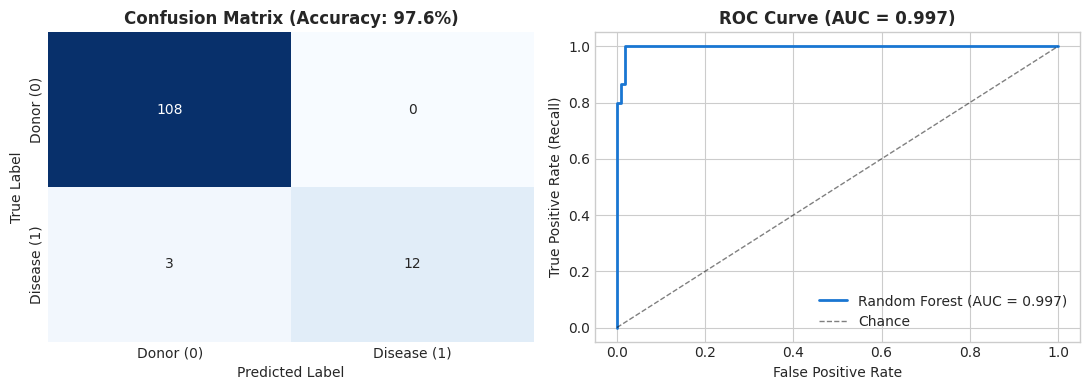

In [ ]:
# Figure 4: Confusion Matrix and ROC Curve
figure, (confusion_matrix_axis, roc_curve_axis) = plt.subplots(
    1, 2,
    figsize=(11, 4)
)

# Confusion Matrix
sns.heatmap(
    confusion_matrix_values,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=confusion_matrix_axis,
    cbar=False
)

confusion_matrix_axis.set_title(
    'Confusion Matrix (Accuracy: 97.6%)',
    fontweight='bold'
)
confusion_matrix_axis.set_xlabel('Predicted Label')
confusion_matrix_axis.set_ylabel('True Label')
confusion_matrix_axis.set_xticklabels(['Donor (0)', 'Disease (1)'])
confusion_matrix_axis.set_yticklabels(['Donor (0)', 'Disease (1)'])


# ROC Curve
false_positive_rate, true_positive_rate, _ = roc_curve(
    testing_target,
    full_panel_probabilities
)

roc_curve_axis.plot(
    false_positive_rate,
    true_positive_rate,
    color='#1976D2',
    lw=2,
    label=f'Random Forest (AUC = {full_panel_roc_auc:.3f})'
)

roc_curve_axis.plot(
    [0, 1],
    [0, 1],
    'k--',
    lw=1,
    alpha=0.5,
    label='Chance'
)

roc_curve_axis.set_xlabel('False Positive Rate')
roc_curve_axis.set_ylabel('True Positive Rate (Recall)')
roc_curve_axis.set_title(
    'ROC Curve (AUC = 0.997)',
    fontweight='bold'
)
roc_curve_axis.legend()

plt.tight_layout()
plt.show()

## 8. Feature Importance
Which biomarkers are most important in detecting liver disease?

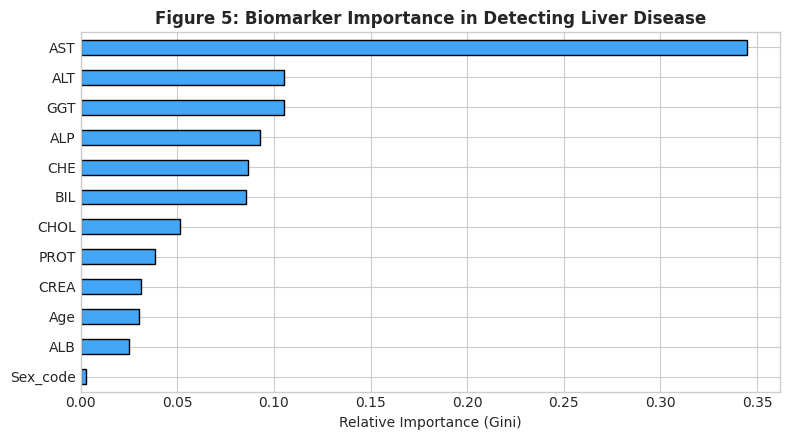

In [ ]:
# Figure 5: Feature Importances
random_forest_classifier = random_forest_full_pipeline.named_steps['classifier']

feature_importances = pd.Series(
    random_forest_classifier.feature_importances_,
    index=full_feature_names
).sort_values(ascending=True)

plt.figure(figsize=(8, 4.5))
feature_importances.plot(
    kind='barh',
    color='#42A5F5',
    edgecolor='black'
)

plt.title(
    'Figure 5: Biomarker Importance in Detecting Liver Disease',
    fontweight='bold'
)

plt.xlabel('Relative Importance (Gini)')
plt.tight_layout()
plt.show()